In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [2]:
# https://www.kaggle.com/datasets/vikasjigupta786/customer-analytics-practice-dataset
df = pd.read_csv("Mall_Customers_Enhanced.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Estimated Savings (k$),Credit Score,Loyalty Years,Preferred Category
0,1,Male,19,15,39,18-25,11.10,456,3,Budget
1,2,Male,21,15,81,18-25,6.90,300,6,Luxury
2,3,Female,20,16,6,18-25,15.36,594,2,Budget
3,4,Female,23,16,77,18-25,7.79,300,6,Luxury
4,5,Female,31,17,40,26-35,12.47,480,5,Budget
...,...,...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,26-35,56.80,850,7,Luxury
196,197,Female,45,126,28,36-50,102.48,850,5,Electronics
197,198,Male,32,126,74,26-35,63.84,850,6,Luxury
198,199,Male,32,137,18,26-35,120.56,850,4,Fashion


In [3]:
# Preprocessing

columns = ['cust_id', 'gender', 'age', 'annual_income', 'spending_score', 'age_group', 
           'estimated_savings', 'credit_score', 'loyalty_years', 'preferred_category']

df.columns = columns

In [4]:
print(df.iloc[:,-1].value_counts())

preferred_category
Electronics    78
Luxury         54
Fashion        41
Budget         27
Name: count, dtype: int64


In [5]:
X = df.iloc[:, 1:-1].drop(['age_group'], axis=1)
y = df.iloc[:, -1]

In [6]:
X.gender = X.gender.map(lambda x: 1 if x=='Male' else 0)

In [7]:
X

,gender,age,annual_income,spending_score,estimated_savings,credit_score,loyalty_years
0,1,19,15,39,11.10,456,3
1,1,21,15,81,6.90,300,6
2,0,20,16,6,15.36,594,2
3,0,23,16,77,7.79,300,6
4,0,31,17,40,12.47,480,5
...,...,...,...,...,...,...,...
195,0,35,120,79,56.80,850,7
196,0,45,126,28,102.48,850,5
197,1,32,126,74,63.84,850,6
198,1,32,137,18,120.56,850,4


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, stratify=y, test_size=0.125) # 25 for testing


In [9]:
y_train.value_counts()

preferred_category
Electronics    68
Luxury         47
Fashion        36
Budget         24
Name: count, dtype: int64

In [10]:
y_test.value_counts()

preferred_category
Electronics    10
Luxury          7
Fashion         5
Budget          3
Name: count, dtype: int64

In [11]:

def evaluate_model(model, name, X_train, X_test, y_train, y_test):

    train_preds = model.predict(X_train)
    test_preds  = model.predict(X_test)

    print(f"\n{name} Results:")
    print("Train Accuracy:", accuracy_score(y_train, train_preds))
    print("Test Results Classification Report:")
    print(classification_report(y_test, test_preds))

# First Classification Method:
# Decision Tree

In [12]:
param_grid = {
    "max_depth": [None] + list(range(3,10)),    
    "min_samples_split": list(range(2,10)),       
    "min_samples_leaf": list(range(2,10)),       
    "class_weight": [None, "balanced"],    
}


In [13]:
skf = StratifiedKFold(n_splits=5)

In [14]:
grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=skf,
    scoring="accuracy", 
    n_jobs=-1 # because the param_grid is a bit big, 1024 options * 5 fold cv
)

In [15]:
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 3, ...], 'min_samples_leaf': [2, 3, ...], 'min_samples_split': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [16]:
evaluate_model(grid, 'Decision Tree', X_train, X_test, y_train, y_test)


Decision Tree Results:
Train Accuracy: 1.0
Test Results Classification Report:
              precision    recall  f1-score   support

      Budget       1.00      1.00      1.00         3
 Electronics       1.00      1.00      1.00        10
     Fashion       1.00      1.00      1.00         5
      Luxury       1.00      1.00      1.00         7

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



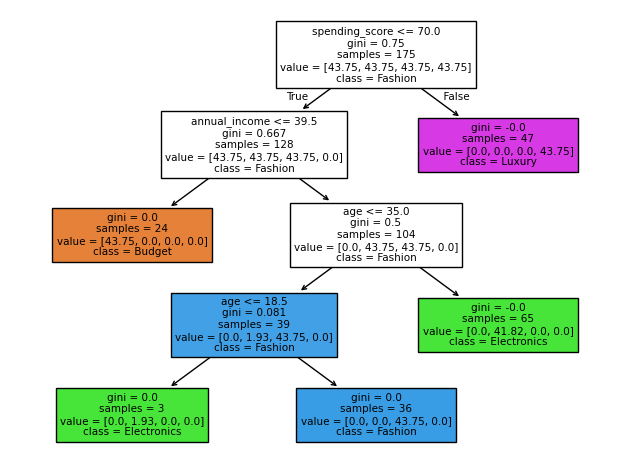

In [17]:
plot_tree(
    grid.best_estimator_,
    feature_names=X.columns,
    filled=True,
    class_names=grid.best_estimator_.classes_.astype(str)
)

plt.tight_layout()
plt.show()

In [18]:
perm = PermutationImportance(grid.best_estimator_, random_state=42)
perm.fit(X_test, y_test)

eli5.show_weights(perm, feature_names=X.columns.to_list())

Weight,Feature
0.4480 ± 0.1920,spending_score
0.2560 ± 0.1484,age
0.2080 ± 0.0933,annual_income
0 ± 0.0000,estimated_savings
0 ± 0.0000,credit_score
0 ± 0.0000,loyalty_years
0 ± 0.0000,gender


# Second Classification Method
# Random Forest

In [19]:
# Second Classification Method
# Random Forest

rf = RandomForestClassifier()
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
evaluate_model(rf, 'Random Forest', X_train, X_test, y_train, y_test)


Random Forest Results:
Train Accuracy: 1.0
Test Results Classification Report:
              precision    recall  f1-score   support

      Budget       1.00      1.00      1.00         3
 Electronics       1.00      1.00      1.00        10
     Fashion       1.00      1.00      1.00         5
      Luxury       1.00      1.00      1.00         7

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



In [21]:
perm = PermutationImportance(rf, random_state=42)
perm.fit(X_test, y_test)

eli5.show_weights(perm, feature_names=X.columns.to_list())

Weight,Feature
0.3920 ± 0.1632,spending_score
0.2560 ± 0.1395,age
0.2080 ± 0.0933,annual_income
0.0160 ± 0.0392,loyalty_years
0 ± 0.0000,credit_score
0 ± 0.0000,estimated_savings
0 ± 0.0000,gender


# Third Classification Method
# Naive Bayes

In [22]:
nb = GaussianNB()
nb.fit(X_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [23]:
evaluate_model(nb, 'Gaussian Naive Bayes', X_train, X_test, y_train, y_test)


Gaussian Naive Bayes Results:
Train Accuracy: 0.9257142857142857
Test Results Classification Report:
              precision    recall  f1-score   support

      Budget       1.00      1.00      1.00         3
 Electronics       1.00      0.90      0.95        10
     Fashion       0.80      0.80      0.80         5
      Luxury       0.88      1.00      0.93         7

    accuracy                           0.92        25
   macro avg       0.92      0.93      0.92        25
weighted avg       0.93      0.92      0.92        25



 Accuracy is a bit lower in GaussianNB compared to a decision tree and random forest. 

In [24]:
perm = PermutationImportance(nb, random_state=42)
perm.fit(X_test, y_test)

eli5.show_weights(perm, feature_names=X.columns.to_list())

Weight,Feature
0.2320 ± 0.1061,spending_score
0.2000 ± 0.0716,age
0.0960 ± 0.1647,loyalty_years
0.0640 ± 0.0640,estimated_savings
0.0560 ± 0.0392,annual_income
0.0160 ± 0.0392,credit_score
-0.0240 ± 0.0392,gender


# Fourth Classification Method
# KNN

KNN requires scaling. so does logistic regression which I will perform after

also need to choose the best k, can use gridsearhcv. 
since i'm going to scale the features then perform CV, it is best to use a pipeline to prevent data leakage

In [25]:
pipe = Pipeline(
    [("scaler", StandardScaler()),
     ("model", KNeighborsClassifier())]
)

In [26]:
param_grid = {
    'model__n_neighbors': list(range(2,8)),
    'model__weights': ['uniform', 'distance']
}

In [27]:
knn_grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy'
)

In [28]:
knn_grid.fit(X_train, y_train) 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [2, 3, ...], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [29]:
k = knn_grid.best_params_['model__n_neighbors']
evaluate_model(knn_grid, f'KNN Regression (k={k})', X_train, X_test, y_train, y_test)


KNN Regression (k=3) Results:
Train Accuracy: 0.9314285714285714
Test Results Classification Report:
              precision    recall  f1-score   support

      Budget       1.00      1.00      1.00         3
 Electronics       0.91      1.00      0.95        10
     Fashion       0.75      0.60      0.67         5
      Luxury       0.86      0.86      0.86         7

    accuracy                           0.88        25
   macro avg       0.88      0.86      0.87        25
weighted avg       0.87      0.88      0.87        25



KNN tuned with k=3 has lower performance than GaussianNB.

In [30]:
perm = PermutationImportance(knn_grid.best_estimator_, random_state=42)
perm.fit(X_test, y_test)

eli5.show_weights(perm, feature_names=X.columns.to_list())

Weight,Feature
0.3200 ± 0.1824,spending_score
0.1280 ± 0.1061,age
0.1040 ± 0.1085,loyalty_years
0.0640 ± 0.0816,annual_income
0.0480 ± 0.0599,estimated_savings
0.0240 ± 0.0640,credit_score
-0.0560 ± 0.0392,gender


# Fifth Classification Method
# Multinomial Logistic Regression


In [31]:
log_pipe = Pipeline(
    [('scaler', StandardScaler()),
     ('model', LogisticRegression())]
)

In [32]:
log_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [33]:
evaluate_model(log_pipe, 'Multinomial Logistic Regression', X_train, X_test, y_train, y_test)


Multinomial Logistic Regression Results:
Train Accuracy: 0.9428571428571428
Test Results Classification Report:
              precision    recall  f1-score   support

      Budget       1.00      1.00      1.00         3
 Electronics       1.00      1.00      1.00        10
     Fashion       1.00      0.80      0.89         5
      Luxury       0.88      1.00      0.93         7

    accuracy                           0.96        25
   macro avg       0.97      0.95      0.96        25
weighted avg       0.96      0.96      0.96        25



In [34]:
eli5.show_weights(
    log_pipe.named_steps['model'],
    feature_names=X.columns.to_list()
)

In [35]:
perm = PermutationImportance(log_pipe, random_state=42)
perm.fit(X_test, y_test)

eli5.show_weights(perm, feature_names=X.columns.to_list())

Weight,Feature
0.2960 ± 0.1085,spending_score
0.2880 ± 0.1782,age
0.1360 ± 0.0640,estimated_savings
0.1360 ± 0.0392,annual_income
0.0640 ± 0.0392,loyalty_years
0 ± 0.0000,credit_score
0 ± 0.0000,gender


In [36]:
perm.feature_importances_

array([0.   , 0.288, 0.136, 0.296, 0.136, 0.   , 0.064])

# Conclusion

The tree models performed perfectly for this dataset as the classes were well organized with regards to their features. Logistic regression performed pretty good as well, and Naive Bayes and KNN performed worse but not too bad. The gender feature isn't helpful at all and could easily be dropped. Spending score is the most important feature for each model.